In [1]:
# Install required library
!pip install sentence-transformers


In [2]:
# Import libraries
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
# 10 sentences across 3 topics: Badminton, Swimming, Data Analytics
sentences = [
    "The player smashed the shuttlecock to win the point",
    "Footwork is very important in badminton matches",
    "A strong backhand shot can change the game",

    "Swimming improves overall body strength and stamina",
    "Freestyle is the fastest swimming stroke",
    "Proper breathing technique is essential in swimming",

    "Data analytics helps in making better business decisions",
    "Visualization tools make data easier to understand",
    "Cleaning data is an important step in analysis",
    "Statistical models are used to find patterns in data"
]

# Short labels for axes (S0-S9)
labels = [f"S{i}" for i in range(len(sentences))]

print("Sentences loaded:")
for i, s in enumerate(sentences):
    print(f"  {labels[i]}: {s}")


In [4]:
# Load pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate sentence embeddings
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")


In [5]:
# Compute pairwise cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print(f"Similarity matrix shape: {similarity_matrix.shape}")


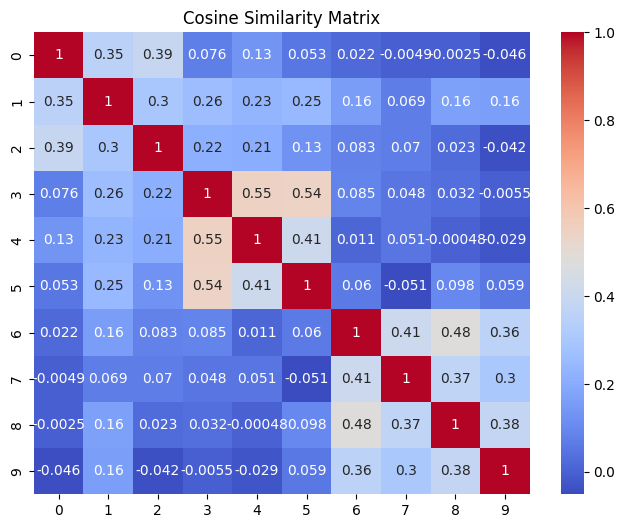

In [6]:
# Plot cosine similarity heatmap with sentence labels on axes
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Cosine Similarity Matrix")
plt.tight_layout()
plt.show()


In [7]:
# Query sentence
query = "The player won the match with a powerful smash"

# Encode query
query_embedding = model.encode([query])

# Compute similarity between query and all sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], "-> Score:", similarities[i])


Top 2 similar sentences:
The player smashed the shuttlecock to win the point -> Score: 0.500202
Footwork is very important in badminton matches -> Score: 0.30555287
